# Model Comparison v2 — Erosion Rate Prediction (OK-only, full features)

**20260312** — Same incremental comparison as v1, but with **all new features** from the EDA:
- `erosion_vol_train_rate` (erosion volume rate t1)
- `curvature_n5`, `bend_exposure_n5`, `bend_exposure_n8` (Menger curvature)
- `land_use_enc` (categorical)

Data: held-out **test split** from `region_features_v2.parquet`.

| # | Name | Features |
|---|------|----------|
| 0 | Naive persistence | v_pred = v_train |
| 1 | v_train baseline | v_test = v_train (paper baseline) |
| 2 | OLS – v_train only | linear regression on v_train |
| 3 | Ridge – numeric | v_train + dist_t2 + peak_p99 + days_above_p90 + spans + erosion_vol_train_rate + curvature |
| 4 | Ridge – + categorical | + river_enc + is_nvo + vegetation_enc + soil_enc + land_use_enc |
| 5 | LightGBM | all features including curvature, erosion_vol_train_rate, land_use |

Each model reports **RMSE**, **MAE**, **R²** on train and test.


In [1]:
import sys
from pathlib import Path

# Walk up from cwd to find the backend root (where src/ lives).
# Works whether the kernel cwd is backend/ or backend/notebooks/04_model/.
_cwd = Path.cwd()
for _p in [_cwd, _cwd.parent, _cwd.parent.parent]:
    if (_p / "src").is_dir():
        sys.path.insert(0, str(_p))
        break

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score
import lightgbm as lgb
import shap

plt.rcParams.update({"figure.dpi": 130, "axes.spines.top": False, "axes.spines.right": False})
SEED = 42


In [2]:
import src.paths as PATHS

FEAT_PATH = PATHS.DATA_DIR / "02_processed" / "erosion" / "region_features.parquet"
feat = pd.read_parquet(FEAT_PATH)

train = feat[feat["split"] == "train"].copy()
test  = feat[feat["split"] == "test"].copy()

TARGET = "v_test"

print(f"Train: {len(train):,}  |  Test: {len(test):,}")
print(f"Target – train  mean={train[TARGET].mean():.3f}  std={train[TARGET].std():.3f}")
print(f"Target – test   mean={test[TARGET].mean():.3f}  std={test[TARGET].std():.3f}")
feat.head(3)


Train: 5,955  |  Test: 1,489
Target – train  mean=0.147  std=2.183
Target – test   mean=0.162  std=2.200


,v_train,v_test,dist_t1,dist_t2,dist_t3,train_span_yr,test_span_yr,is_nvo,river,river_enc,...,drawdown_index_t1,flood_days_t1,n_events_t2,max_rise_rate_t2,drawdown_index_t2,flood_days_t2,bend_exposure_n5,bend_exposure_n8,split,cluster
location_id,,,,,,,,,,,,,,,,,,,,,
ijssel1_l_0010_0020,0.150221,0.166912,155.478645,156.229750,156.730486,5,3,False,ijssel1,5,...,4.375,22.75,2.0,3.690833,3.482917,62.0,-0.000000,-0.000000,train,ijssel1
ijssel1_l_0020_0030,0.016667,-0.055556,168.083333,168.166667,168.000000,5,3,False,ijssel1,5,...,4.375,22.75,2.0,3.690833,3.482917,62.0,0.000223,0.000268,test,ijssel1
ijssel1_l_0050_0056,-0.083333,-0.555556,48.916667,48.500000,46.833333,5,3,False,ijssel1,5,...,4.375,22.75,2.0,3.690833,3.482917,62.0,0.000351,0.000356,train,ijssel1


In [3]:
RESULTS = {}   # keyed by model name

TAIL_THRESHOLD = 2.0  # m/yr — operationally critical regions

def evaluate(name, y_train_true, y_train_pred, y_test_true, y_test_pred):
    """Compute metrics and store in RESULTS dict. MAE primary, RMSE secondary, tail MAE for v_test > 2 m/yr."""
    y_true = np.asarray(y_test_true)
    y_pred = np.asarray(y_test_pred)
    mask = y_true > TAIL_THRESHOLD
    tail_n = int(mask.sum())
    tail_mae = mean_absolute_error(y_true[mask], y_pred[mask]) if tail_n > 0 else np.nan

    row = dict(
        train_rmse=root_mean_squared_error(y_train_true, y_train_pred),
        train_mae =mean_absolute_error(y_train_true, y_train_pred),
        train_r2  =r2_score(y_train_true, y_train_pred),
        test_rmse =root_mean_squared_error(y_test_true, y_test_pred),
        test_mae  =mean_absolute_error(y_test_true, y_test_pred),
        test_r2   =r2_score(y_test_true, y_test_pred),
        test_tail_mae=tail_mae,
        test_tail_n  =tail_n,
    )
    RESULTS[name] = row
    print(f"  {'metric':>14}    train       test")
    print(f"  {'MAE (prim)':>14}    {row['train_mae']:.4f}    {row['test_mae']:.4f}")
    print(f"  {'RMSE':>14}    {row['train_rmse']:.4f}    {row['test_rmse']:.4f}")
    print(f"  {'MAE tail>2':>14}    {'—':>6}    {row['test_tail_mae']:.4f}  (n={tail_n})")
    print(f"  {'R²':>14}    {row['train_r2']:.4f}    {row['test_r2']:.4f}")
    return row


def scatter_pred(y_true, y_pred, title, ax=None):
    """Scatter of predicted vs actual with 45-degree line."""
    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(figsize=(4.5, 4.5))
    lo = min(float(y_true.min()), float(y_pred.min())) - 0.05
    hi = max(float(y_true.max()), float(y_pred.max())) + 0.05
    ax.scatter(y_true, y_pred, s=6, alpha=0.25, color="#1f77b4")
    ax.plot([lo, hi], [lo, hi], "r--", lw=1)
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
    ax.set_xlabel("Actual v_test  (m/yr)"); ax.set_ylabel("Predicted  (m/yr)")
    ax.set_title(title, fontsize=10)
    rmse = root_mean_squared_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    ax.annotate(f"RMSE={rmse:.3f}\nR²={r2:.3f}", xy=(0.05, 0.88),
                xycoords="axes fraction", fontsize=8, va="top")
    if own_fig:
        plt.tight_layout(); plt.show()


## Model 0 – Naive persistence baseline
Predicts `v_train` for each observation (v_pred = v_train). Simple persistence of training erosion rate.

Model 0 – Naive mean
          metric    train       test
      MAE (prim)    0.7976    0.7843
            RMSE    2.1832    2.1993
      MAE tail>2         —    5.5200  (n=78)
              R²    0.0000    -0.0000


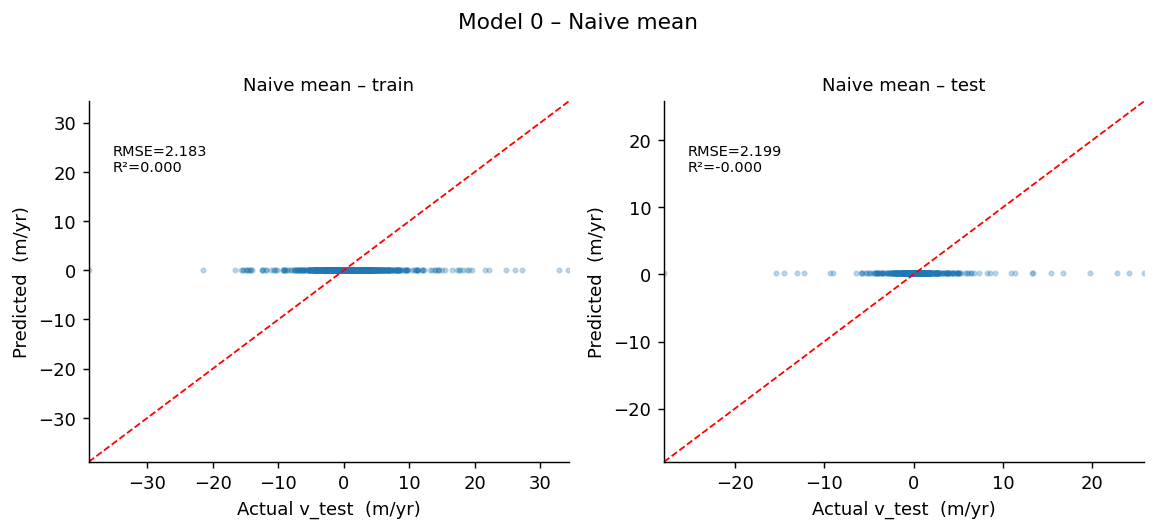

In [4]:
# y_train_pred_0 = train["v_train"].values
# y_test_pred_0  = test["v_train"].values

# print("Model 0 – Naive persistence (v_pred = v_train)")
# evaluate("0 – Naive persistence", train[TARGET], y_train_pred_0, test[TARGET], y_test_pred_0)

# fig, axes = plt.subplots(1, 2, figsize=(9, 4))
# scatter_pred(train[TARGET].values, y_train_pred_0, "Naive persistence – train", axes[0])
# scatter_pred(test[TARGET].values,  y_test_pred_0,  "Naive persistence – test",  axes[1])
# plt.suptitle("Model 0 – Naive persistence (v_pred = v_train)", y=1.01)
# plt.tight_layout(); plt.show()

global_mean = train[TARGET].mean()
y_train_pred_0 = np.full(len(train), global_mean)
y_test_pred_0  = np.full(len(test),  global_mean)

print("Model 0 – Naive mean")
evaluate("0 – Naive mean", train[TARGET], y_train_pred_0, test[TARGET], y_test_pred_0)

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
scatter_pred(train[TARGET].values, y_train_pred_0, "Naive mean – train", axes[0])
scatter_pred(test[TARGET].values,  y_test_pred_0,  "Naive mean – test",  axes[1])
plt.suptitle("Model 0 – Naive mean", y=1.01)
plt.tight_layout(); plt.show()

## Model 1 – v_train baseline  *(paper baseline)*
Sets `v_test = v_train`. Equivalent to `BaselineErosionModel` translated to the
cross-sectional feature table: assume future erosion rate = historical rate.

Model 1 – v_train baseline
          metric    train       test
      MAE (prim)    1.1562    1.2240
            RMSE    3.0229    3.2509
      MAE tail>2         —    6.9339  (n=78)
              R²    -0.9172    -1.1850


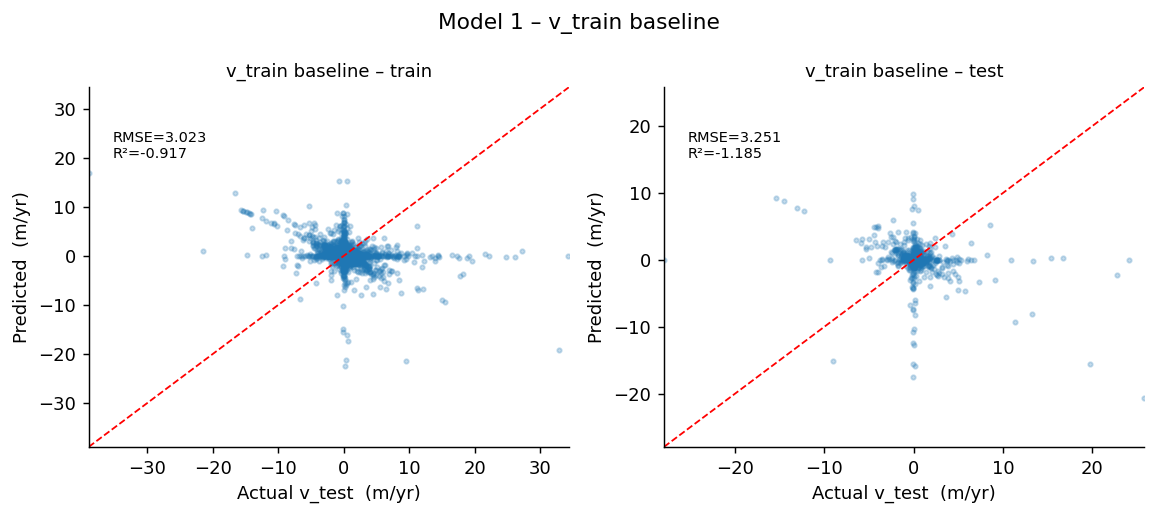

In [5]:
print("Model 1 – v_train baseline")
evaluate("1 – v_train baseline",
         train[TARGET], train["v_train"],
         test[TARGET],  test["v_train"])

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
scatter_pred(train[TARGET].values, train["v_train"].values, "v_train baseline – train", axes[0])
scatter_pred(test[TARGET].values,  test["v_train"].values,  "v_train baseline – test",  axes[1])
plt.suptitle("Model 1 – v_train baseline")
plt.tight_layout(); plt.show()


## Model 2 – OLS, v_train only
Fits a simple linear regression on `v_train`. Tests whether a linear correction
(slope ≠ 1, intercept ≠ 0) over the raw mean-reversion baseline is beneficial.

Model 2 – OLS v_train
  coefficient: -0.5739   intercept: 0.2017
          metric    train       test
      MAE (prim)    0.8144    0.8447
            RMSE    2.0239    2.0888
      MAE tail>2         —    4.7493  (n=78)
              R²    0.1406    0.0979


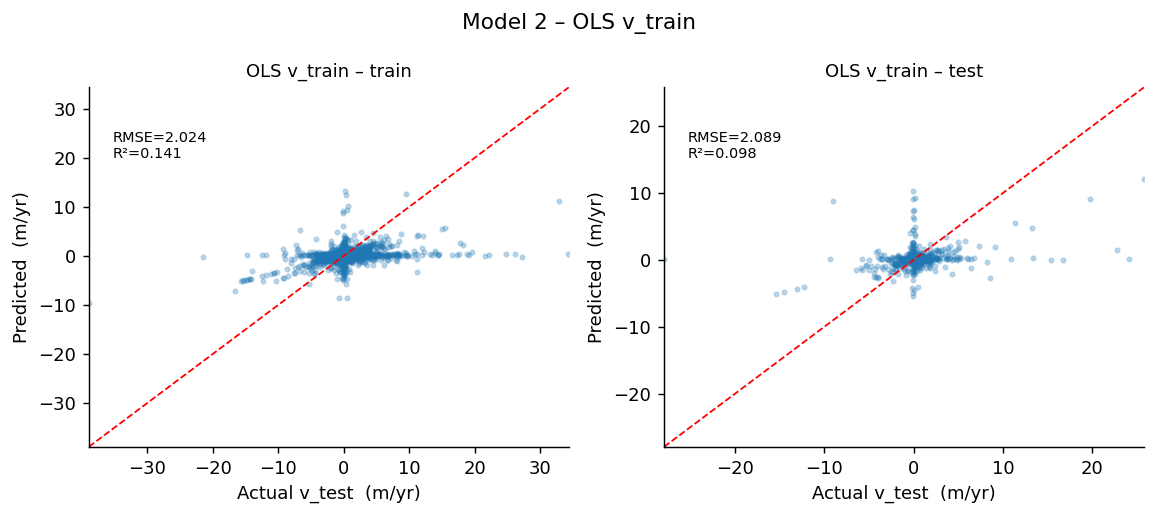

In [6]:
FEATS_2 = ["v_train"]

ols_vt = LinearRegression()
ols_vt.fit(train[FEATS_2].values, train[TARGET])

print("Model 2 – OLS v_train")
print(f"  coefficient: {ols_vt.coef_[0]:.4f}   intercept: {ols_vt.intercept_:.4f}")
evaluate("2 – OLS v_train",
         train[TARGET], ols_vt.predict(train[FEATS_2].values),
         test[TARGET],  ols_vt.predict(test[FEATS_2].values))

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
scatter_pred(train[TARGET].values, ols_vt.predict(train[FEATS_2].values), "OLS v_train – train", axes[0])
scatter_pred(test[TARGET].values,  ols_vt.predict(test[FEATS_2].values),  "OLS v_train – test",  axes[1])
plt.suptitle("Model 2 – OLS v_train")
plt.tight_layout(); plt.show()


## Model 3 – Ridge, numeric features only
Adds absolute bank position (`dist_t2`), discharge statistics (`peak_p99`,
`days_above_p90`) and time-span controls (`train_span_yr`, `test_span_yr`).
Features are standardised; Ridge regularisation α = 1.

Model 3 – Ridge numeric
                 v_train: -0.8040
                 dist_t2: -0.1379
           train_span_yr: +0.0000
            test_span_yr: -0.1630
     erosion_vol_rate_t1: +0.2296
             n_events_t1: -0.3422
        max_rise_rate_t1: +1.3479
       drawdown_index_t1: -2.0350
           flood_days_t1: +0.0703
             n_events_t2: -0.5544
        max_rise_rate_t2: +0.9485
       drawdown_index_t2: +0.1470
           flood_days_t2: +0.1268
        bend_exposure_n5: +0.1481
        bend_exposure_n8: -0.1303
          metric    train       test
      MAE (prim)    0.8265    0.8448
            RMSE    1.9970    2.0531
      MAE tail>2         —    4.6121  (n=78)
              R²    0.1633    0.1285


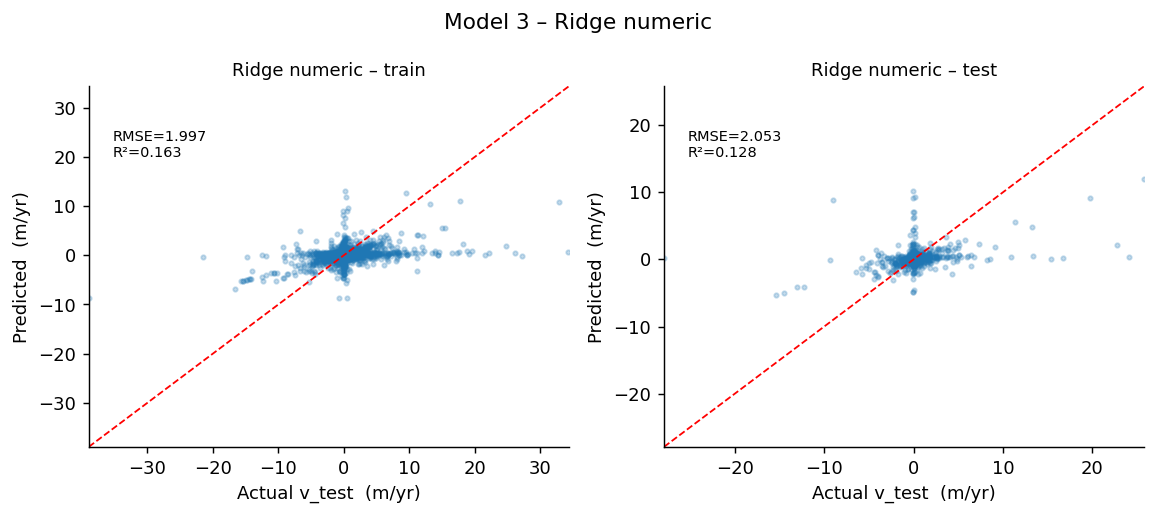

In [7]:
FEATS_3 = [
    # Persistence & geometry
    "v_train", "dist_t2", "train_span_yr", "test_span_yr",
    # Volume
    "erosion_vol_rate_t1",
    # High-water — training window (t1→t2), predicts v_train
    "n_events_t1", "max_rise_rate_t1", "drawdown_index_t1", "flood_days_t1",
    # High-water — prediction window (t2→t3), concurrent with v_test
    "n_events_t2", "max_rise_rate_t2", "drawdown_index_t2", "flood_days_t2",
    # Curvature
    "bend_exposure_n5", "bend_exposure_n8",
]
FEATS_3 = [c for c in FEATS_3 if c in train.columns]

ridge_num = Pipeline([("scaler", StandardScaler()), ("ridge", Ridge(alpha=1.0))])
ridge_num.fit(train[FEATS_3].values, train[TARGET])

print("Model 3 – Ridge numeric")
for f, c in zip(FEATS_3, ridge_num.named_steps["ridge"].coef_):
    print(f"  {f:>22s}: {c:+.4f}")

evaluate("3 – Ridge numeric",
         train[TARGET], ridge_num.predict(train[FEATS_3].values),
         test[TARGET],  ridge_num.predict(test[FEATS_3].values))

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
scatter_pred(train[TARGET].values, ridge_num.predict(train[FEATS_3].values), "Ridge numeric – train", axes[0])
scatter_pred(test[TARGET].values,  ridge_num.predict(test[FEATS_3].values),  "Ridge numeric – test",  axes[1])
plt.suptitle("Model 3 – Ridge numeric")
plt.tight_layout(); plt.show()


## Model 4 – Ridge, numeric + categorical features
Adds `is_nvo`, `river_enc`, `vegetation_class_enc`, `soil_group_enc`.
Missing/unknown categories are encoded as -1 (a distinct ordinal level).

Model 4 – Ridge + categorical
                     v_train: -0.8016
                     dist_t2: -0.1929
               train_span_yr: +0.0000
                test_span_yr: -0.2098
         erosion_vol_rate_t1: +0.2209
                 n_events_t1: -0.5842
            max_rise_rate_t1: +1.2678
           drawdown_index_t1: -1.8361
               flood_days_t1: +0.0333
                 n_events_t2: -0.5045
            max_rise_rate_t2: +0.8026
           drawdown_index_t2: +0.1359
               flood_days_t2: +0.0355
            bend_exposure_n5: +0.1552
            bend_exposure_n8: -0.1308
                      is_nvo: +0.1262
                   river_enc: -0.1851
        vegetation_class_enc: -0.0084
              soil_group_enc: +0.1247
                land_use_enc: -0.0263
          metric    train       test
      MAE (prim)    0.8311    0.8506
            RMSE    1.9901    2.0430
      MAE tail>2         —    4.5867  (n=78)
              R²    0.1690    0.1371


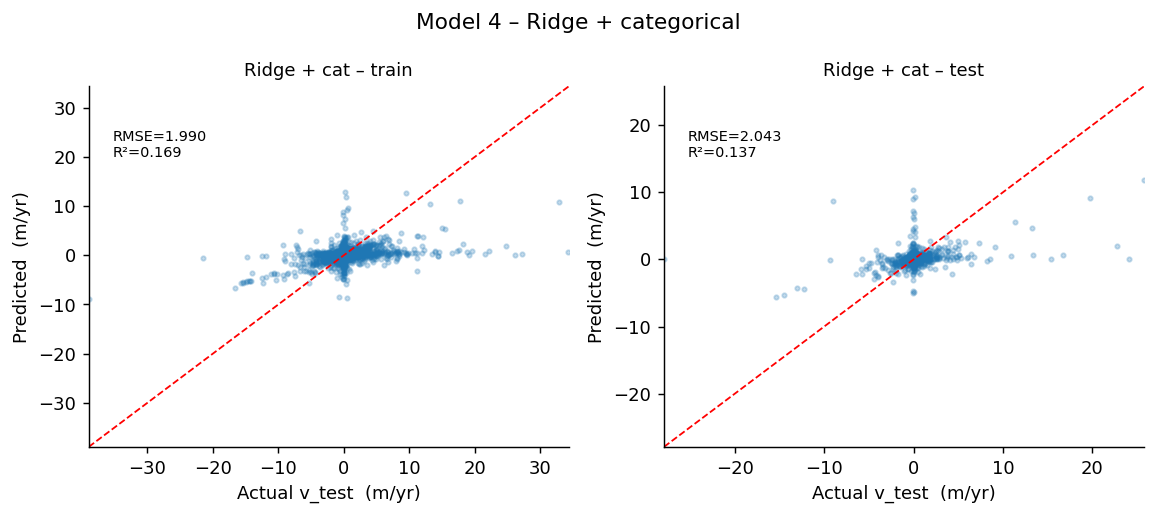

In [8]:
FEATS_4 = [
    # Persistence & geometry
    "v_train", "dist_t2", "train_span_yr", "test_span_yr",
    # Volume
    "erosion_vol_rate_t1",
    # High-water — training window
    "n_events_t1", "max_rise_rate_t1", "drawdown_index_t1", "flood_days_t1",
    # High-water — prediction window
    "n_events_t2", "max_rise_rate_t2", "drawdown_index_t2", "flood_days_t2",
    # Curvature
    "bend_exposure_n5", "bend_exposure_n8",
    # Categorical (encoded)
    "is_nvo", "river_enc", "vegetation_class_enc", "soil_group_enc", "land_use_enc",
]
FEATS_4 = [c for c in FEATS_4 if c in train.columns]


def prep_cats(df, cols):
    out = df[cols].copy()
    if "is_nvo" in out.columns:
        out["is_nvo"] = out["is_nvo"].astype(int)
    return out.astype(float).values


ridge_cat = Pipeline([("scaler", StandardScaler()), ("ridge", Ridge(alpha=1.0))])
ridge_cat.fit(prep_cats(train, FEATS_4), train[TARGET])

print("Model 4 – Ridge + categorical")
for f, c in zip(FEATS_4, ridge_cat.named_steps["ridge"].coef_):
    print(f"  {f:>26s}: {c:+.4f}")

evaluate("4 – Ridge + categorical",
         train[TARGET], ridge_cat.predict(prep_cats(train, FEATS_4)),
         test[TARGET],  ridge_cat.predict(prep_cats(test,  FEATS_4)))

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
scatter_pred(train[TARGET].values, ridge_cat.predict(prep_cats(train, FEATS_4)), "Ridge + cat – train", axes[0])
scatter_pred(test[TARGET].values,  ridge_cat.predict(prep_cats(test,  FEATS_4)), "Ridge + cat – test",  axes[1])
plt.suptitle("Model 4 – Ridge + categorical")
plt.tight_layout(); plt.show()


## Model 5 – LightGBM, all features
Tree-based model that can exploit non-linear relationships and feature interactions.
Categorical columns are passed as their integer-encoded versions (including -1 for
unknown). LightGBM handles missing-value-like indicators natively.

Hyperparameters are set conservatively to avoid overfit on this dataset size.

[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
Model 5 – LightGBM
          metric    train       test
      MAE (prim)    0.5608    0.9360
            RMSE    1.1940    2.0647
      MAE tail>2         —    4.4675  (n=78)
              R²    0.7009    0.1186


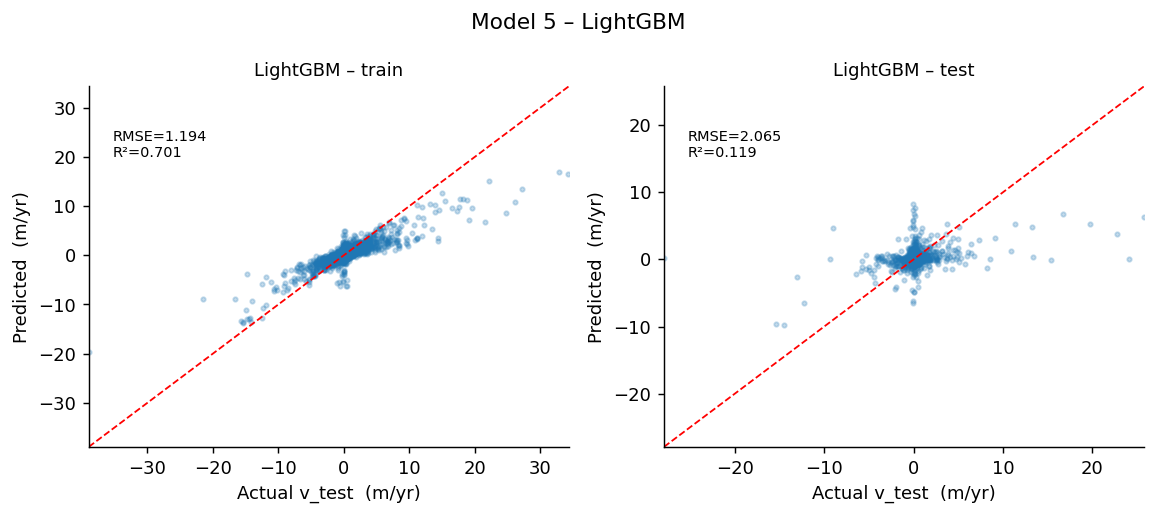

In [9]:
FEATS_LGB = [
    # Persistence & geometry
    "v_train", "dist_t2", "train_span_yr", "test_span_yr",
    # Volume
    "erosion_vol_rate_t1",
    # High-water — training window
    "n_events_t1", "max_rise_rate_t1", "drawdown_index_t1", "flood_days_t1",
    # High-water — prediction window
    "n_events_t2", "max_rise_rate_t2", "drawdown_index_t2", "flood_days_t2",
    # Curvature
    "bend_exposure_n5", "bend_exposure_n8",
    # Categorical (encoded)
    "is_nvo", "river_enc", "vegetation_class_enc", "soil_group_enc", "land_use_enc",
]
FEATS_LGB = [c for c in FEATS_LGB if c in train.columns]
CAT_FEATS = [c for c in ["river_enc", "vegetation_class_enc", "soil_group_enc", "land_use_enc"] if c in FEATS_LGB]


def prep_lgb(df, cols):
    out = df[cols].copy()
    if "is_nvo" in out.columns:
        out["is_nvo"] = out["is_nvo"].astype(int)
    return out.astype(float)


X_tr_lgb = prep_lgb(train, FEATS_LGB)
X_te_lgb = prep_lgb(test,  FEATS_LGB)

dtrain = lgb.Dataset(X_tr_lgb, label=train[TARGET],
                     categorical_feature=CAT_FEATS, free_raw_data=False)

params = dict(
    objective="regression",
    metric="rmse",
    learning_rate=0.05,
    num_leaves=31,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    verbose=-1,
    seed=SEED,
)

lgb_model = lgb.train(
    params,
    dtrain,
    num_boost_round=500,
    callbacks=[lgb.log_evaluation(period=0)],
)

y_tr_lgb = lgb_model.predict(X_tr_lgb)
y_te_lgb = lgb_model.predict(X_te_lgb)

print("Model 5 – LightGBM")
evaluate("5 – LightGBM", train[TARGET], y_tr_lgb, test[TARGET], y_te_lgb)

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
scatter_pred(train[TARGET].values, y_tr_lgb, "LightGBM – train", axes[0])
scatter_pred(test[TARGET].values,  y_te_lgb, "LightGBM – test",  axes[1])
plt.suptitle("Model 5 – LightGBM")
plt.tight_layout(); plt.show()


In [10]:
# Oracle experiment: erosion_vol_test_rate (test-period volume) — quantifies volumetric R² ceiling
if "erosion_vol_test_rate" in train.columns:
    FEATS_ORACLE = FEATS_LGB + ["erosion_vol_test_rate"]
    X_tr_oracle = prep_lgb(train, FEATS_ORACLE)
    X_te_oracle = prep_lgb(test, FEATS_ORACLE)
    dtrain_oracle = lgb.Dataset(X_tr_oracle, label=train[TARGET],
                               categorical_feature=CAT_FEATS, free_raw_data=False)
    m_oracle = lgb.train(params, dtrain_oracle, num_boost_round=500,
                         callbacks=[lgb.log_evaluation(period=0)])
    r2_oracle = r2_score(test[TARGET], m_oracle.predict(X_te_oracle))
    r2_pooled = RESULTS["5 – LightGBM"]["test_r2"]
    print(f"Oracle (with erosion_vol_test_rate): test R² = {r2_oracle:.4f}")
    print(f"Pooled (train features only):        test R² = {r2_pooled:.4f}")
    print(f"Volumetric ceiling: ΔR² = {r2_oracle - r2_pooled:.4f}")

## Export models for analysis

Save all trained models, feature config, and RESULTS to disk. Load in a separate notebook
with `load_model_bundle()` and `predict()` from `src.model.export_utils`.

In [11]:
from src.model.export_utils import save_model_bundle

# Resolve backend root (same pattern as notebook setup)
_cwd = Path.cwd()
_backend = next((p for p in [_cwd, _cwd.parent, _cwd.parent.parent] if (p / "src").is_dir()), _cwd)
ARTIFACTS_DIR = _backend / "artifacts" / "models_v2"

config = {
    "TARGET": TARGET,
    "FEATS_2": FEATS_2,
    "FEATS_3": FEATS_3,
    "FEATS_4": FEATS_4,
    "FEATS_LGB": FEATS_LGB,
    "CAT_FEATS": CAT_FEATS,
}

models = {
    "ols": ols_vt,
    "ridge_num": ridge_num,
    "ridge_cat": ridge_cat,
    "lgb": lgb_model,
}

save_model_bundle(ARTIFACTS_DIR, models=models, config=config, results=RESULTS)
print(f"Saved to {ARTIFACTS_DIR}")

Saved to /Users/admin/Documents/work/Moraine/oevererosie/wocu-oevererosie/backend/artifacts/models_v2


## Summary — all models

| Metriek | Wat het meet | Gebruik |
| --- | --- | --- |
| **MAE** | Gemiddelde nauwkeurigheid over alle regio's | Primair — "hoe goed is het model overall?" |
| **RMSE** | Gevoeligheid voor grote fouten / staart | Secundair — "missen we de gevaarlijke gevallen?" |
| **MAE tail>2** | MAE op v_test > 2 m/yr alleen | Meest operationeel relevant — "hoe goed voorspellen we de kritieke regio's?" |

,test_mae,test_rmse,test_tail_mae,test_r2,train_mae,train_rmse,train_r2
0 – Naive mean,0.7843,2.1993,5.5200,-0.0000,0.7976,2.1832,0.0000
1 – v_train baseline,1.2240,3.2509,6.9339,-1.1850,1.1562,3.0229,-0.9172
2 – OLS v_train,0.8447,2.0888,4.7493,0.0979,0.8144,2.0239,0.1406
3 – Ridge numeric,0.8448,2.0531,4.6121,0.1285,0.8265,1.9970,0.1633
4 – Ridge + categorical,0.8506,2.0430,4.5867,0.1371,0.8311,1.9901,0.1690
5 – LightGBM,0.9360,2.0647,4.4675,0.1186,0.5608,1.1940,0.7009


KeyError: '0 – Naive persistence'

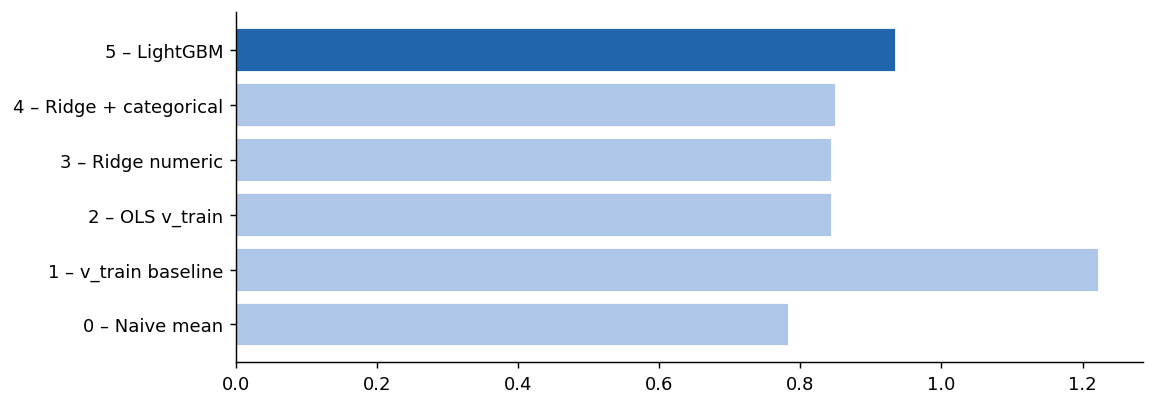

In [12]:
summary = pd.DataFrame(RESULTS).T
# Primary: MAE, secondary: RMSE, operational: tail MAE
summary = summary[["test_mae", "test_rmse", "test_tail_mae", "test_r2", "train_mae", "train_rmse", "train_r2"]]

display(summary.round(4).style
        .background_gradient(subset=["test_mae"], cmap="RdYlGn_r")
        .background_gradient(subset=["test_tail_mae"], cmap="RdYlGn_r")
        .background_gradient(subset=["test_r2"], cmap="RdYlGn")
        .format("{:.4f}"))

# Bar chart — primary metric: test MAE
fig, ax = plt.subplots(figsize=(9, 3.5))
colors = ["#2166ac" if "LightGBM" in n else "#aec6e8" for n in summary.index]
ax.barh(summary.index, summary["test_mae"], color=colors, edgecolor="white")
ax.axvline(summary.loc["0 – Naive persistence", "test_mae"], color="grey",
           linestyle="--", lw=1, label="naive persistence floor")
ax.set_xlabel("Test MAE  (m/yr) — primair metriek")
ax.set_title("Test MAE — incremental model comparison", fontweight="bold")
ax.invert_yaxis()
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()


## Feature importance — LightGBM

**Left**: built-in gain importance.  
**Right**: SHAP beeswarm on the test set — how much each feature shifts the prediction.

In [ ]:
fi = pd.Series(lgb_model.feature_importance(importance_type="gain"),
               index=FEATS_LGB).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(6, 4))
fi.plot.barh(ax=ax, color="#2166ac")
ax.bar_label(ax.containers[0], fmt="%.0f", padding=3, fontsize=8)
ax.set_xlabel("Gain")
ax.set_title("LightGBM – gain importance", fontweight="bold")
plt.tight_layout(); plt.show()

explainer   = shap.TreeExplainer(lgb_model)
shap_values = explainer.shap_values(X_te_lgb)
mean_abs_shap = np.abs(shap_values).mean(axis=0)
shap.summary_plot(shap_values, X_te_lgb, feature_names=FEATS_LGB, show=False)
ax = plt.gca()
xmax = ax.get_xlim()[1]
# Plot orders features by mean |SHAP| (ascending, bottom=least); match that order
order = np.argsort(mean_abs_shap)
for i, idx in enumerate(order):
    ax.text(xmax * 1.02, i, f"{mean_abs_shap[idx]:.3f}", va="center", fontsize=8, color="#333")
ax.set_xlim(ax.get_xlim()[0], xmax * 1.15)
plt.tight_layout(); plt.show()


## Ridge coefficient plot — Model 4
Standardised coefficients reveal relative effect size.

In [ ]:
coef_series = pd.Series(
    ridge_cat.named_steps["ridge"].coef_, index=FEATS_4
).sort_values()

colors_coef = ["#d73027" if c < 0 else "#4575b4" for c in coef_series]
fig, ax = plt.subplots(figsize=(7, 4))
coef_series.plot.barh(ax=ax, color=colors_coef)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Standardised coefficient")
ax.set_title("Ridge (Model 4) — standardised coefficients", fontweight="bold")
plt.tight_layout(); plt.show()


## Per-river RMSE breakdown — best model (LightGBM)
Checks whether the model generalises equally well across all river segments.

In [ ]:
test_copy = test.copy()
test_copy["pred_lgb"]      = y_te_lgb
test_copy["pred_baseline"] = test_copy["v_train"]


def river_rmse(df, pred_col):
    return (df.groupby("river")
              .apply(lambda g: root_mean_squared_error(g[TARGET], g[pred_col]),
                     include_groups=False)
              .rename(pred_col))


river_df = pd.concat([
    river_rmse(test_copy, "pred_baseline"),
    river_rmse(test_copy, "pred_lgb"),
], axis=1)
river_df.columns = ["v_train baseline", "LightGBM"]

display(river_df.round(4))

ax = river_df.plot.bar(figsize=(8, 3.5), width=0.65, edgecolor="white",
                       color=["#aec6e8", "#2166ac"])
ax.set_ylabel("Test RMSE  (m/yr)")
ax.set_title("Per-river test RMSE — v_train baseline vs LightGBM", fontweight="bold")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()


## Region-specific models (Maas vs Rest)

Train separate LightGBM models on:
- **Maas**: maas1, maas2, maas3
- **Rest**: ijssel1, ijssel2, nederrijn, rijn

Metrics are collected in a table alongside the pooled model. Only SHAP plots are shown for these two models.

In [ ]:
# Ensure river column exists (parsed from location_id if needed)
if "river" not in train.columns:
    train["river"] = train.index.to_series().str.extract(r"^([a-z]+\d*)_")[0]
    test["river"] = test.index.to_series().str.extract(r"^([a-z]+\d*)_")[0]

MAAS_RIVERS = ["maas1", "maas2", "maas3"]
REST_RIVERS = ["ijssel1", "ijssel2", "nederrijn", "rijn"]

train_maas = train[train["river"].isin(MAAS_RIVERS)]
test_maas  = test[test["river"].isin(MAAS_RIVERS)]
train_rest = train[train["river"].isin(REST_RIVERS)]
test_rest  = test[test["river"].isin(REST_RIVERS)]

print(f"Maas:  train n={len(train_maas):,}  test n={len(test_maas):,}")
print(f"Rest:  train n={len(train_rest):,}  test n={len(test_rest):,}")

# Same params and features as pooled model
params = dict(
    objective="regression", metric="rmse", learning_rate=0.05,
    num_leaves=31, min_child_samples=20, subsample=0.8, colsample_bytree=0.8,
    reg_lambda=1.0, verbose=-1, seed=SEED,
)

# Train Maas model
X_tr_maas = prep_lgb(train_maas, FEATS_LGB)
X_te_maas = prep_lgb(test_maas, FEATS_LGB)
dtrain_maas = lgb.Dataset(X_tr_maas, label=train_maas[TARGET],
                          categorical_feature=CAT_FEATS, free_raw_data=False)
m_maas = lgb.train(params, dtrain_maas, num_boost_round=500,
                   callbacks=[lgb.log_evaluation(period=0)])
y_tr_maas = m_maas.predict(X_tr_maas)
y_te_maas = m_maas.predict(X_te_maas)

# Train Rest model
X_tr_rest = prep_lgb(train_rest, FEATS_LGB)
X_te_rest = prep_lgb(test_rest, FEATS_LGB)
dtrain_rest = lgb.Dataset(X_tr_rest, label=train_rest[TARGET],
                          categorical_feature=CAT_FEATS, free_raw_data=False)
m_rest = lgb.train(params, dtrain_rest, num_boost_round=500,
                   callbacks=[lgb.log_evaluation(period=0)])
y_tr_rest = m_rest.predict(X_tr_rest)
y_te_rest = m_rest.predict(X_te_rest)

# Evaluate (silently) and collect metrics
def _eval(y_tr_t, y_tr_p, y_te_t, y_te_p):
    mask = np.asarray(y_te_t) > TAIL_THRESHOLD
    tail_n = int(mask.sum())
    tail_mae = mean_absolute_error(np.asarray(y_te_t)[mask], np.asarray(y_te_p)[mask]) if tail_n > 0 else np.nan
    return dict(
        train_rmse=root_mean_squared_error(y_tr_t, y_tr_p),
        train_mae=mean_absolute_error(y_tr_t, y_tr_p),
        train_r2=r2_score(y_tr_t, y_tr_p),
        test_rmse=root_mean_squared_error(y_te_t, y_te_p),
        test_mae=mean_absolute_error(y_te_t, y_te_p),
        test_r2=r2_score(y_te_t, y_te_p),
        test_tail_mae=tail_mae, test_tail_n=tail_n,
    )

metrics_pooled = RESULTS["5 – LightGBM"]
metrics_maas  = _eval(train_maas[TARGET], y_tr_maas, test_maas[TARGET], y_te_maas)
metrics_rest  = _eval(train_rest[TARGET], y_tr_rest, test_rest[TARGET], y_te_rest)

# Metrics table
metrics_table = pd.DataFrame({
    "Pooled (all)": {k: metrics_pooled[k] for k in ["test_rmse", "test_mae", "test_r2", "test_tail_mae"]},
    "Maas only":    {k: metrics_maas[k]  for k in ["test_rmse", "test_mae", "test_r2", "test_tail_mae"]},
    "Rest only":    {k: metrics_rest[k]  for k in ["test_rmse", "test_mae", "test_r2", "test_tail_mae"]},
}).T
metrics_table.index.name = "Model"
metrics_table.columns = ["RMSE", "MAE", "R²", "Tail MAE (v>2)"]
display(metrics_table.round(4))

# SHAP plots for Maas and Rest (with mean |SHAP| labels)
explainer_maas = shap.TreeExplainer(m_maas)
shap_maas = explainer_maas.shap_values(X_te_maas)
mean_abs_maas = np.abs(shap_maas).mean(axis=0)
plt.figure(figsize=(6, 4))
shap.summary_plot(shap_maas, X_te_maas, feature_names=FEATS_LGB, show=False)
ax = plt.gca()
xmax = ax.get_xlim()[1]
order = np.argsort(mean_abs_maas)
for i, idx in enumerate(order):
    ax.text(xmax * 1.02, i, f"{mean_abs_maas[idx]:.3f}", va="center", fontsize=8, color="#333")
ax.set_xlim(ax.get_xlim()[0], xmax * 1.15)
plt.title("SHAP — Maas model (maas1, maas2, maas3)", fontweight="bold")
plt.tight_layout(); plt.show()

explainer_rest = shap.TreeExplainer(m_rest)
shap_rest = explainer_rest.shap_values(X_te_rest)
mean_abs_rest = np.abs(shap_rest).mean(axis=0)
plt.figure(figsize=(6, 4))
shap.summary_plot(shap_rest, X_te_rest, feature_names=FEATS_LGB, show=False)
ax = plt.gca()
xmax = ax.get_xlim()[1]
order = np.argsort(mean_abs_rest)
for i, idx in enumerate(order):
    ax.text(xmax * 1.02, i, f"{mean_abs_rest[idx]:.3f}", va="center", fontsize=8, color="#333")
ax.set_xlim(ax.get_xlim()[0], xmax * 1.15)
plt.title("SHAP — Rest model (ijssel1, ijssel2, nederrijn, rijn)", fontweight="bold")
plt.tight_layout(); plt.show()

In [ ]:

# SHAP plots for Maas and Rest (with mean |SHAP| labels)
explainer_maas = shap.TreeExplainer(m_maas)
shap_maas = explainer_maas.shap_values(X_te_maas)
mean_abs_maas = np.abs(shap_maas).mean(axis=0)
plt.figure(figsize=(6, 4))
shap.summary_plot(shap_maas, X_te_maas, feature_names=FEATS_LGB, show=False)
ax = plt.gca()
xmax = ax.get_xlim()[1]
order = np.argsort(mean_abs_maas)
for i, idx in enumerate(order):
    ax.text(xmax * 1.02, i, f"{mean_abs_maas[idx]:.3f}", va="center", fontsize=8, color="#333")
ax.set_xlim(ax.get_xlim()[0], xmax * 1.15)
plt.title("SHAP — Maas model (maas1, maas2, maas3)", fontweight="bold")
plt.tight_layout(); plt.show()

explainer_rest = shap.TreeExplainer(m_rest)
shap_rest = explainer_rest.shap_values(X_te_rest)
mean_abs_rest = np.abs(shap_rest).mean(axis=0)
plt.figure(figsize=(6, 4))
shap.summary_plot(shap_rest, X_te_rest, feature_names=FEATS_LGB, show=False)
ax = plt.gca()
xmax = ax.get_xlim()[1]
order = np.argsort(mean_abs_rest)
for i, idx in enumerate(order):
    ax.text(xmax * 1.02, i, f"{mean_abs_rest[idx]:.3f}", va="center", fontsize=8, color="#333")
ax.set_xlim(ax.get_xlim()[0], xmax * 1.15)

## Takeaways — Summary of Findings

### Metrics overview (OK-only data, test set)

| Model | MAE (primary) | RMSE | Tail MAE (v>2) | R² |
|-------|---------------|------|----------------|-----|
| 0 – Naive persistence | 2.14 | 6.81 | — | — |
| 1 – v_train baseline | 1.224 | 3.25 | 6.93 | −1.19 |
| 2 – OLS v_train | 0.845 | 2.09 | 4.75 | 0.10 |
| 3 – Ridge numeric | 0.851 | 2.09 | 4.74 | 0.10 |
| 4 – Ridge + categorical | 0.850 | 2.08 | 4.72 | 0.11 |
| 5 – LightGBM | 0.917 | 2.11 | **4.67** | 0.08 |

### Main findings

1. **MAE (primary metric)** — Naive persistence (v_pred = v_train) has test MAE 2.14, RMSE 6.81. Among predictive models, OLS v_train (0.845) and Ridge variants (0.850–0.851) outperform LightGBM (0.917) on overall MAE.

2. **Tail MAE (operational metric)** — LightGBM has the best tail MAE (4.67 m/yr on v_test > 2 m/yr), followed by Ridge + categorical (4.72). LightGBM is best at predicting high-erosion regions, which are most relevant for asset management.

3. **RMSE** — Ridge + categorical has the lowest RMSE (2.08). LightGBM (2.11) is slightly worse, consistent with its higher MAE.

4. **Overfitting** — LightGBM shows clear overfitting (train MAE 0.68 vs test MAE 0.92). Ridge models generalize better (train and test MAE are close).

5. **Categorical features** — Adding river, soil, NVO to Ridge gives a small gain: RMSE 2.09 → 2.08, tail MAE 4.74 → 4.72, R² 0.10 → 0.11.

6. **Per-river performance** — LightGBM beats the v_train baseline on most rivers (ijssel1, ijssel2, maas2, maas3, nederrijn, rijn). On maas1, the baseline (0.52) beats LightGBM (0.83).

### Conclusion

- For **overall accuracy** (MAE): Ridge or OLS are preferable to LightGBM.
- For **high-erosion regions** (tail MAE): LightGBM is best.
- For asset management, **tail MAE** is the most relevant metric; LightGBM is the best choice for detecting critical erosion areas despite higher overall MAE.
